In [1]:


"""
不要让所有的参数共享同一个学习率,从而根据每个参数过去的梯度大小,为每个参数自动调整有效学习率
    - 经常被更新的参数,后面走得更加谨慎一些
    - 很少被更新的参数,出现的时候可以走的相对大一些
"""
from collections.abc import Iterable
from typing import override, Any

import dnnlpy
import dnnlpy.optim as dopt
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor

print("PyTorch version: ", torch.__version__)


PyTorch version:  2.13.0+cpu


In [2]:
"""
Adagrad 的核心想法
    根据每个参数过去的累计的梯度大小,自动降低那些经常被答复更新的学习率
"""

'\nAdagrad 的核心想法\n    根据每个参数过去的累计的梯度大小,自动降低那些经常被答复更新的学习率\n'

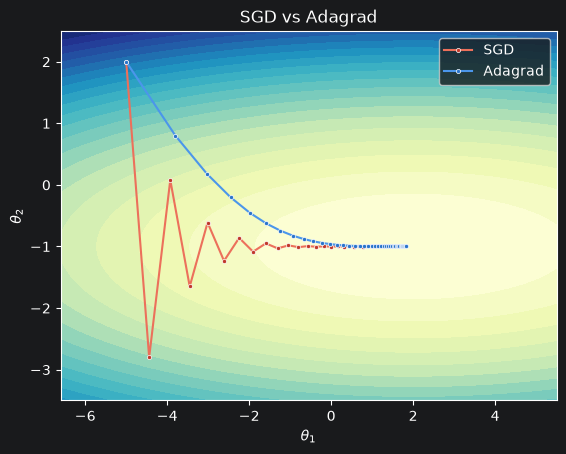

In [11]:
"""
Adagrad 与SGD 的轨迹对比
"""
from typing import List


def loss_fn(theta: Tensor) -> Tensor:
    x, y = theta[0], theta[1]
    return 0.1 * (x - 2) ** 2 + 2 * (y + 1) ** 2


class Adagrad(dopt.Optimizer):
    def __init__(self, params: Iterable[Tensor], lr: float = 1e-2, lr_decay: float = 0.0, weight_decay: float = 0.0,
                 initial_accumulator_value: float = 0.0,
                 eps: float = 1e-10):

        super().__init__(params)
        self.lr = lr
        self.lr_decay = lr_decay
        self.weight_decay = weight_decay
        self.initial_accumulator_value = initial_accumulator_value
        self.eps = eps
        self.step_count = 0
        self.sum_sq_grads = [
            torch.full_like(p, initial_accumulator_value) for p in self.params
        ]
        self.effective_lrs = []

    @override
    @torch.no_grad()
    def step(self):
        self.step_count += 1
        clr = self.lr / (1 + (self.step_count - 1) * self.lr_decay)
        for p, s in zip(self.params, self.sum_sq_grads, strict=True):
            if p.grad is None:
                continue
            grad = p.grad
            if self.weight_decay > 0:
                grad = grad.add(p, alpha=self.weight_decay)
            s.add_(grad.square())
            p.sub_(clr / (s.sqrt() + self.eps) * grad)
        self.effective_lrs.append(self.get_effective_lr())

    @torch.no_grad()
    def get_effective_lr(self) -> List[Tensor]:
        effective_lrs = []

        for s in self.sum_sq_grads:
            lr = self.lr / (s.sqrt() + self.eps).clone()
            effective_lrs.append(lr)
        return effective_lrs


theta1 = torch.tensor([-5.0, 2.0], requires_grad=True)
theta2 = torch.tensor([-5.0, 2.0], requires_grad=True)
optimizer1 = dopt.SGD([theta1], lr=0.4)
optimizer2 = Adagrad([theta2], lr=1.2)

sgd_history = dopt.run_optimizer(optimizer1, loss_fn=loss_fn, steps=40)
adagrad_history = dopt.run_optimizer(optimizer2, loss_fn=loss_fn, steps=40)

x = torch.linspace(-6.6, 5.5, 200)
y = torch.linspace(-3.5, 2.5, 200)

X, Y = torch.meshgrid(x, y, indexing='ij')
Z = 0.1 * (X - 2) ** 2 + 2.0 * (Y + 1) ** 2

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.contourf(X, Y, Z, levels=25, cmap="YlGnBu")
ax.plot(
    sgd_history[:, 0],
    sgd_history[:, 1],
    color="#EC705B",
    marker="o",
    markersize=3,
    markeredgecolor="white",
    markerfacecolor="#C0392B",
    markeredgewidth=0.5,
)
ax.plot(
    adagrad_history[:, 0],
    adagrad_history[:, 1],
    color="#4B96EB",
    marker="o",
    markersize=3,
    markeredgecolor="white",
    markerfacecolor="#2A74CB",
    markeredgewidth=0.5,
)

ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")
ax.legend(['SGD', 'Adagrad'])
ax.set_title("SGD vs Adagrad")
plt.show()



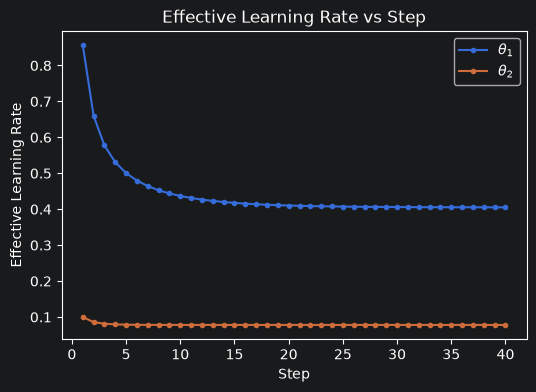

In [12]:
"""
Adagrad有效学习率可视化
"""
lr_history = torch.stack([lr[0] for lr in optimizer2.effective_lrs])
steps = torch.arange(1, lr_history.size(0) + 1)

fig = plt.figure(2, figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)
ax.plot(steps, lr_history[:, 0], marker="o", markersize=3)
ax.plot(steps, lr_history[:, 1], marker="o", markersize=3)
ax.set_xlabel('Step')
ax.set_ylabel("Effective Learning Rate")
ax.legend([r'$\theta_1$', r'$\theta_2$'])
ax.set_title("Effective Learning Rate vs Step")
plt.show()

In [ ]:
"""
Adagrad 与 SGD与Mementum  的关系
- Mementum 关注的是方向的平滑和加速
- Adagrad  关注的是不同参数步长的缩放
"""